<a href="https://colab.research.google.com/github/SaddiManisha/heart_failure_perdiction_ML/blob/main/23029912_Manisha_Saddi_Heart_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imported all Libraries

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

# Load the dataset from kaggle

In [ ]:
# Download latest version
path = kagglehub.dataset_download("aadarshvelu/heart-failure-prediction-clinical-records")

print("Path to dataset files:", path)

100%|██████████| 28.6k/28.6k [00:00<00:00, 6.19MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aadarshvelu/heart-failure-prediction-clinical-records/versions/1


In [ ]:
# Load the data
hr_df = pd.read_csv(path + "/heart_failure_clinical_records.csv")

In [ ]:
# Print the dataframe
hr_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45.0,0,582,1,55,0,543000.00,1.0,132,0,0,250,0
4996,60.0,1,582,0,30,1,127000.00,0.9,145,0,0,95,0
4997,95.0,1,112,0,40,1,196000.00,1.0,138,0,0,24,1
4998,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# EDA (Exploratory data analysis)

In [ ]:
# Checking dataset information
print(hr_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   float64
 1   anaemia                   5000 non-null   int64  
 2   creatinine_phosphokinase  5000 non-null   int64  
 3   diabetes                  5000 non-null   int64  
 4   ejection_fraction         5000 non-null   int64  
 5   high_blood_pressure       5000 non-null   int64  
 6   platelets                 5000 non-null   float64
 7   serum_creatinine          5000 non-null   float64
 8   serum_sodium              5000 non-null   int64  
 9   sex                       5000 non-null   int64  
 10  smoking                   5000 non-null   int64  
 11  time                      5000 non-null   int64  
 12  DEATH_EVENT               5000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 507.9 KB
None


In [ ]:
# Checking Statistics values
display(hr_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,5000.0,60.288736,11.697243,40.0,50.0,60.00,68.0,95.0
anaemia,5000.0,0.474400,0.499394,0.0,0.0,0.00,1.0,1.0
creatinine_phosphokinase,5000.0,586.760600,976.733979,23.0,121.0,248.00,582.0,7861.0
diabetes,5000.0,0.439400,0.496364,0.0,0.0,0.00,1.0,1.0
ejection_fraction,5000.0,37.734600,11.514855,14.0,30.0,38.00,45.0,80.0
high_blood_pressure,5000.0,0.364800,0.481422,0.0,0.0,0.00,1.0,1.0
platelets,5000.0,265075.404370,97999.758622,25100.0,215000.0,263358.03,310000.0,850000.0
serum_creatinine,5000.0,1.369106,1.009750,0.5,0.9,1.10,1.4,9.4
serum_sodium,5000.0,136.808200,4.464236,113.0,134.0,137.00,140.0,148.0
sex,5000.0,0.645600,0.478379,0.0,0.0,1.00,1.0,1.0


In [ ]:
# checking missing values
print(hr_df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# checking target feature count
print(hr_df['DEATH_EVENT'].value_counts())

DEATH_EVENT
0    3432
1    1568
Name: count, dtype: int64


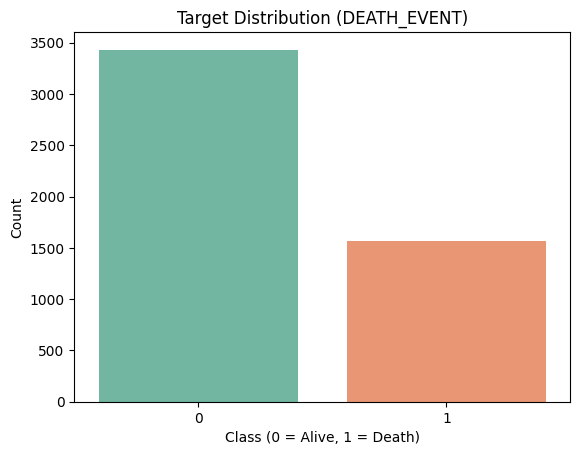

In [ ]:
# Plot the target feature count
sns.countplot(x=hr_df['DEATH_EVENT'], palette="Set2")
plt.title("Target Distribution (DEATH_EVENT)")
plt.xlabel("Class (0 = Alive, 1 = Death)")
plt.ylabel("Count")
plt.show()

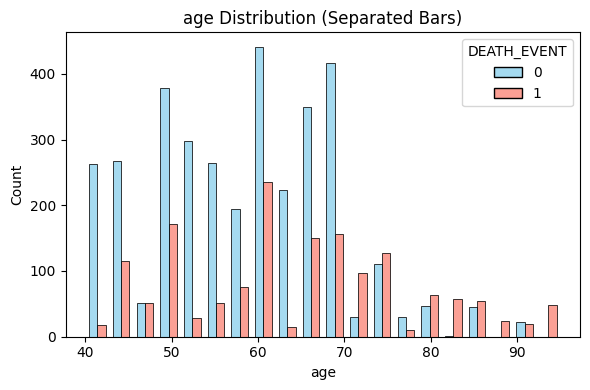

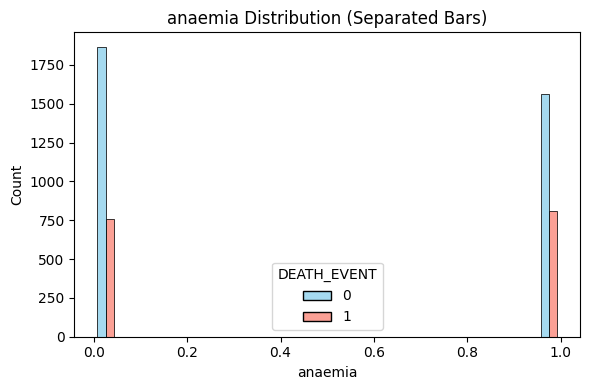

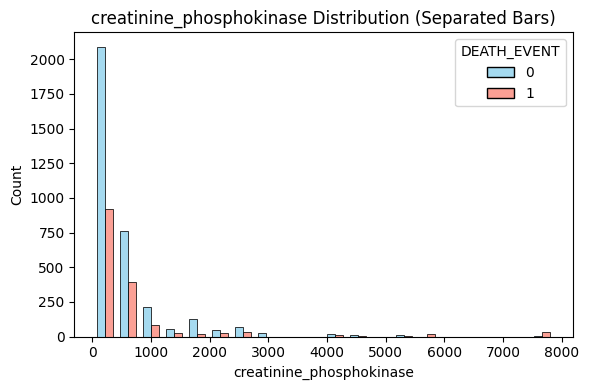

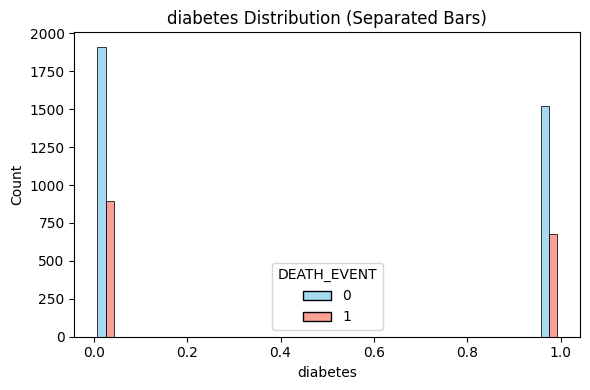

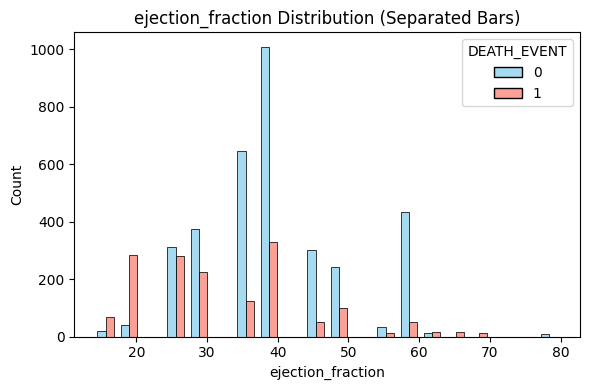

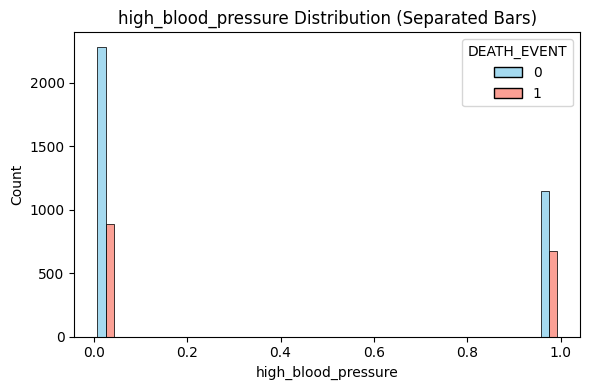

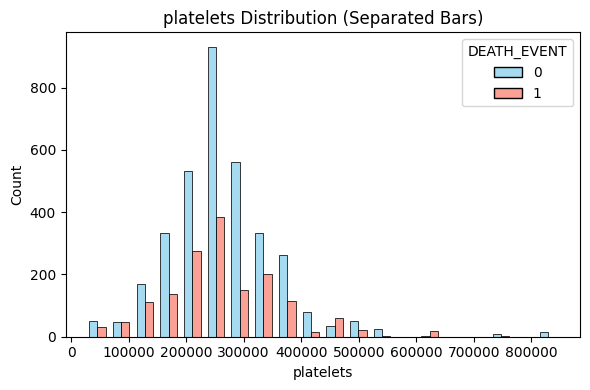

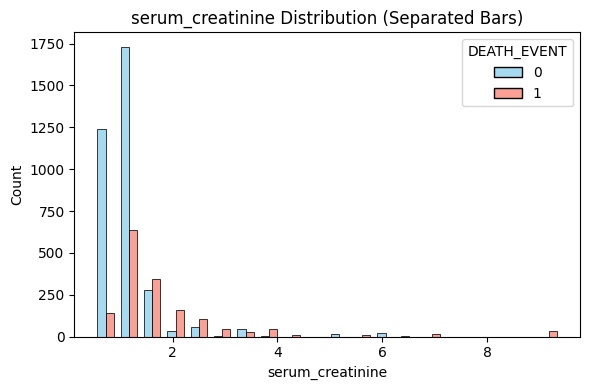

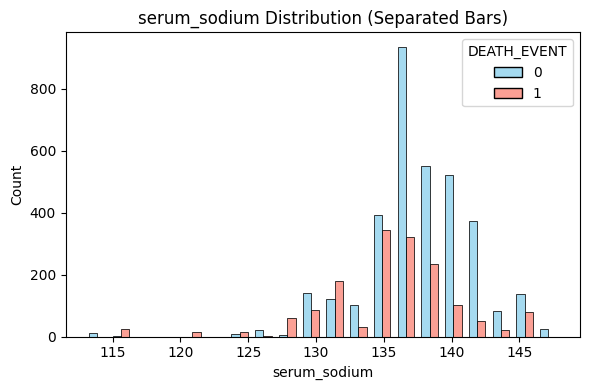

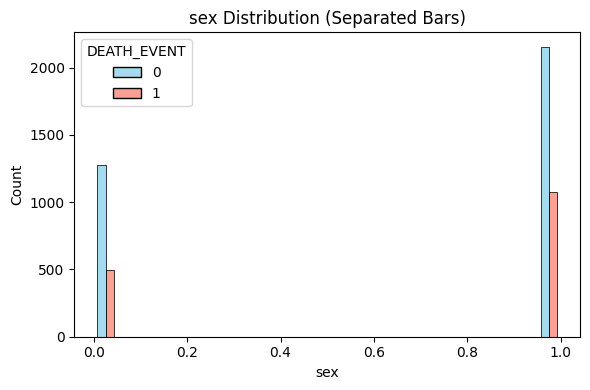

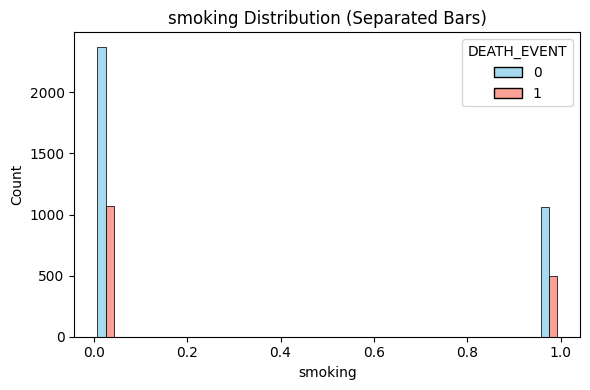

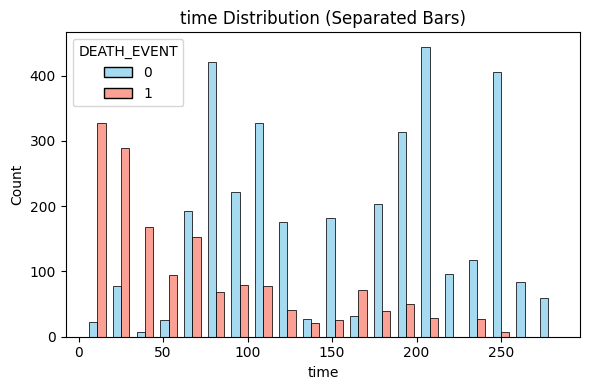

In [ ]:
numeric_cols = hr_df.drop("DEATH_EVENT", axis=1).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=hr_df,
        x=col,
        hue="DEATH_EVENT",
        bins=20,
        multiple="dodge",
        shrink=0.7,
        palette=["skyblue", "salmon"]
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

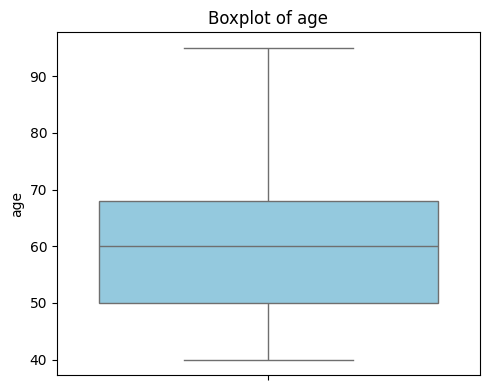

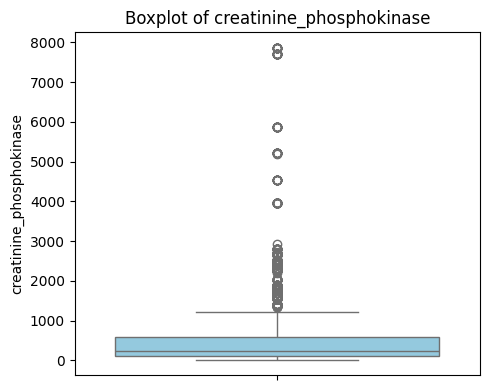

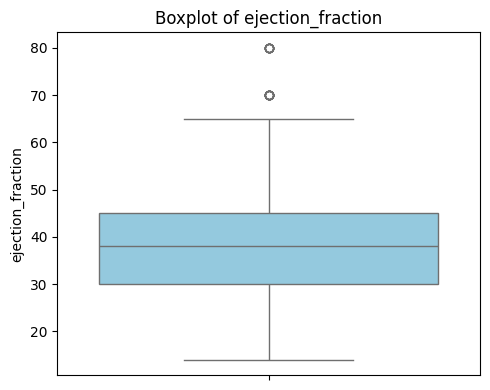

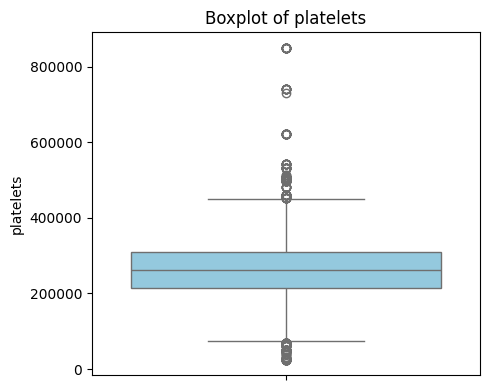

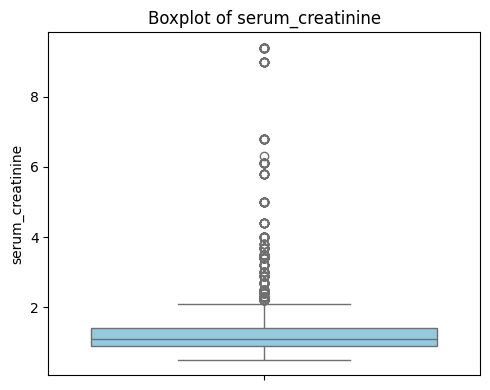

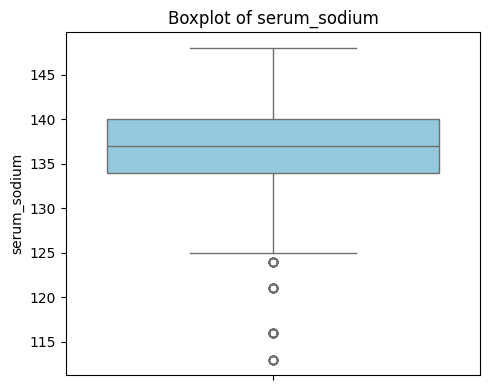

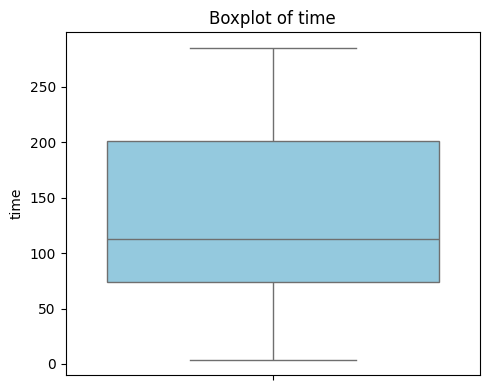

In [ ]:
# Final 7 continuous features
boxplot_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

# Boxplots for these features
for col in boxplot_features:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=hr_df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

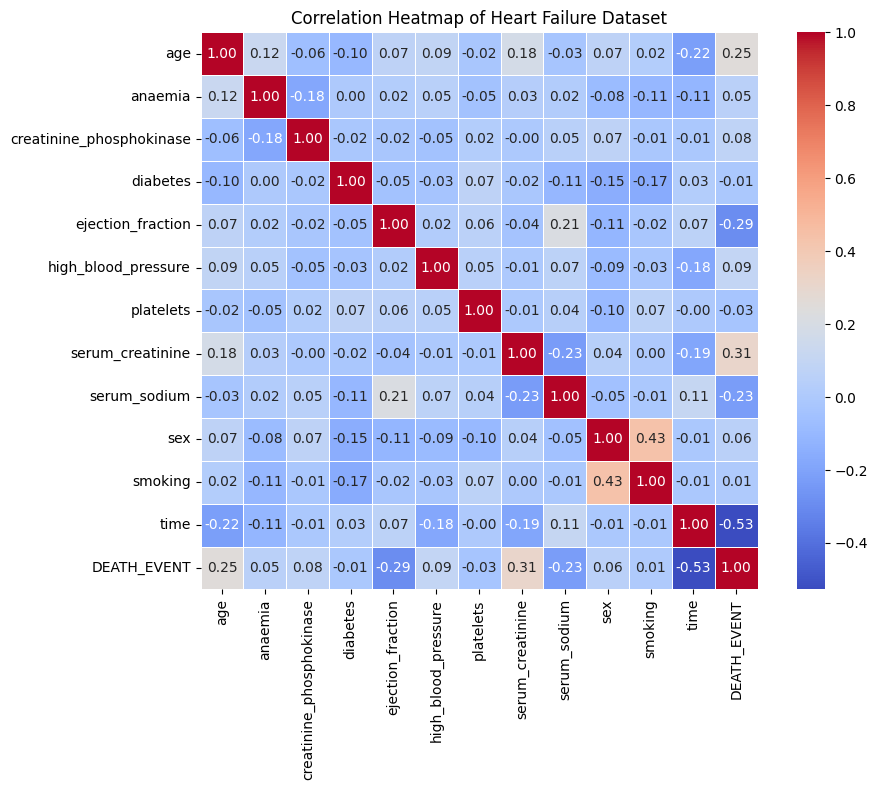

In [ ]:
plt.figure(figsize=(10,8))
corr = hr_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Heart Failure Dataset")
plt.tight_layout()
plt.show()

# Preprocessing

In [ ]:
# Separate independent and dependant features
X = hr_df.drop("DEATH_EVENT", axis=1)
y = hr_df["DEATH_EVENT"]

print("Data separated: Features (X) and Target (y)")
print("X shape:", X.shape)
print("y shape:", y.shape)

Data separated: Features (X) and Target (y)
X shape: (5000, 12)
y shape: (5000,)


In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split completed.")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Data split completed.
Train shape: (4000, 12)
Test shape: (1000, 12)


In [ ]:
# train data - Target distribution
print("Target distribution:\n", y_train.value_counts())

Target distribution:
 DEATH_EVENT
0    2746
1    1254
Name: count, dtype: int64


In [ ]:
# test data - Target distribution
print("Target distribution:\n", y_test.value_counts())

Target distribution:
 DEATH_EVENT
0    686
1    314
Name: count, dtype: int64


In [ ]:
# Balance ONLY the training data using SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Class distribution AFTER SMOTE:")
print(y_train_bal.value_counts())


Class distribution AFTER SMOTE:
DEATH_EVENT
1    2746
0    2746
Name: count, dtype: int64


In [ ]:
# Standardization (Scaling the data)
scaler = StandardScaler()

# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print("Data standardized using StandardScaler")

Data standardized using StandardScaler


In [ ]:
# Print full data after scaling
X_train_scaled

array([[ 0.6958774 , -0.96106333, -0.32823967, ..., -1.36070045,
        -0.6667105 , -0.62221681],
       [ 1.10539069,  1.04051415, -0.01372158, ...,  0.73491561,
        -0.6667105 , -0.01983182],
       [-1.35168904, -0.96106333, -0.01372158, ..., -1.36070045,
        -0.6667105 ,  1.67197285],
       ...,
       [-0.0685201 ,  1.04051415, -0.47488614, ...,  0.73491561,
        -0.6667105 ,  0.7235369 ],
       [ 0.6958774 , -0.96106333, -0.01372158, ...,  0.73491561,
         1.49990138, -1.07080138],
       [-1.35168904,  1.04051415,  0.3712254 , ...,  0.73491561,
        -0.6667105 , -1.32713542]])

In [ ]:
# checking first row data
X_train_scaled[3]

array([ 0.6958774 , -0.96106333, -0.32823967, -0.87127996, -0.94289138,
       -0.75768727, -0.17848791, -0.25429259,  1.20197378, -1.36070045,
       -0.6667105 , -0.62221681])

# Model implementation

## Model Evalution function

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    # Predict
    y_pred = model.predict(X_test)

    # Print classification report
    print(f"\n {model_name} - Classification Report")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Survived (0)", "Death (1)"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

## 1. Logistic Regression

In [ ]:
# Train Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train_bal)

LogisticRegression()

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[ 6.13192588e-01  9.57190344e-02  4.21239449e-01 -6.85596500e-03
  -1.03152324e+00 -1.18959936e-03 -3.67256818e-02  8.42818899e-01
  -4.41285731e-01 -2.40591627e-02 -6.14277001e-02 -1.59748350e+00]]
[0.0457945]



 Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.90      0.81      0.86       686
           1       0.66      0.80      0.73       314

    accuracy                           0.81      1000
   macro avg       0.78      0.81      0.79      1000
weighted avg       0.83      0.81      0.82      1000



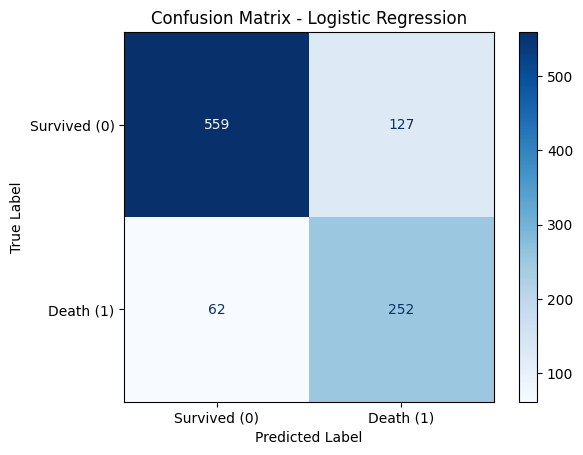

In [ ]:
evaluate_model(lr,X_test_scaled, y_test, "Logistic Regression")

## 2. KNN

In [ ]:
# Train K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_bal)

KNeighborsClassifier()


 KNN - Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       686
           1       0.97      0.95      0.96       314

    accuracy                           0.98      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000



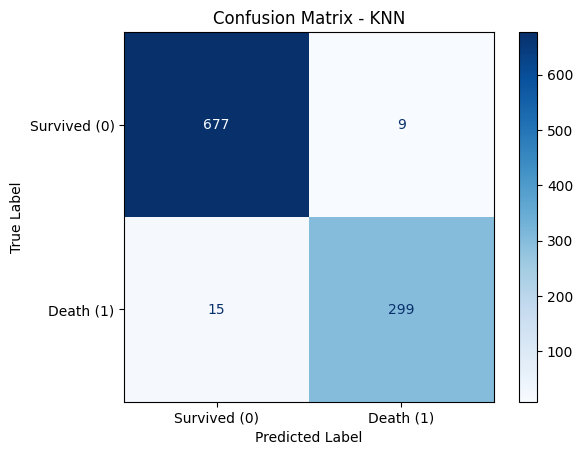

In [ ]:
evaluate_model(knn,X_test_scaled, y_test, "KNN")